In [ ]:
import glob
import os
from pathlib import Path

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import napari

import skimage
from scipy import ndimage as ndi
from skimage import measure, segmentation, filters
from skimage.measure import regionprops

from pathlib import Path

### Importing and loading

In [ ]:
# Import images - ADJUST relative path names
# Please provide the path to the runs directory

images_runs_dir = Path(r'/Volumes/gmicro_prefect/gchao/bamfaile/Gitrepos_temp2/gchao_singlemolecule_tracking/runs')
image_dir = images_runs_dir / 'iNeurons'/'iNeurons_predictions'/'03_Predict'/'ACTB'/'50ms'/'20250219'/'Parthenolide8hrs'
image_path = os.path.join(image_dir,'*.stk') 
image_files = np.sort(glob.glob(image_path))

mask_cell_runs_dir = Path(r'/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Whole_cell')
mask_cell_dir = mask_cell_runs_dir
mask_cell_path = os.path.join(mask_cell_dir,'*.tif') 
mask_cell_files = np.sort(glob.glob(mask_cell_path))

mask_nucleus_runs_dir = Path(r'/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Nucleus')
mask_nucleus_dir = mask_cell_runs_dir
mask_nucleus_path = os.path.join(mask_nucleus_dir,'*.tif') 
mask_nucleus_files = np.sort(glob.glob(mask_nucleus_path))

print(len(image_files))
print(len(mask_cell_files))
print(len(mask_nucleus_files))

In [ ]:
# Read images into list

images = []

for file in image_files:
    image = imread(file)
    images.append(image)

In [ ]:
plt.imshow(images[-1][0])

In [164]:
# Read images into list

mask_cell = []
mask_nucleus = []

for file in mask_cell_files:
    image = imread(file)
    mask_cell.append(image)

for file in mask_nucleus_files:
    image = imread(file)
    mask_nucleus.append(image)

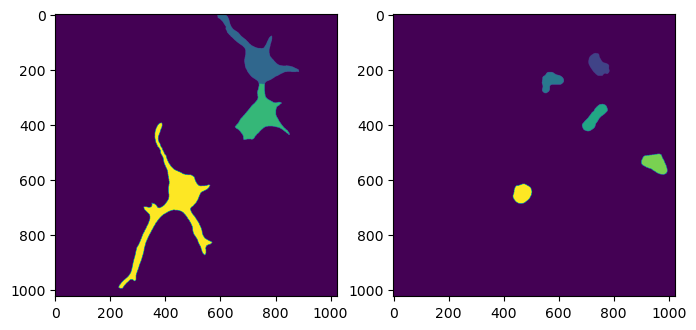

In [165]:
# Plot whole cell and nucleus mask side by side

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_cell[-2])
ax[1].imshow(mask_nucleus[-2])

### Correcting nuclei

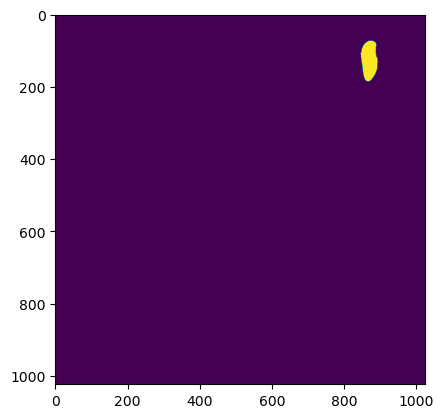

In [166]:
# Create copies of cytoplasm masks for manipulation in Napari

mask_nucleus_copy = mask_nucleus.copy()
plt.imshow(mask_nucleus_copy[-1])

In [ ]:
# Initializes Napari viewer

viewer = napari.Viewer()

Invalid schema for package 'ome-types', please run 'npe2 validate ome-types' to check for manifest errors.


In [167]:
# Adds images to Napari viewer

for i, img in enumerate(images):
    layer_name = f'image_{i}'  # Dynamically name each layer
    viewer.add_image(img, name=layer_name)

In [168]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_nucleus_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=0.2)

### Watershedding from nucleus to separate cell masks

In [ ]:
# Watershed using the nucleus as seed to separate the overlapping cell masks

mask_label=[]
distance_maps = []

for cell, nucleus in zip(mask_cell, mask_nucleus_copy):
    
    # Smooth the distance transform of the cell mask
    distance_map = ndi.distance_transform_edt(cell)
    smoothed_distance_map = filters.gaussian(distance_map, sigma=1)
    distance_maps.append(smoothed_distance_map)

    # Use the nuclei labels as markers
    markers = measure.label(nucleus)

    # Apply the watershed algorithm
    labels = segmentation.watershed(-smoothed_distance_map, markers, mask=cell)
    mask_label.append(labels)

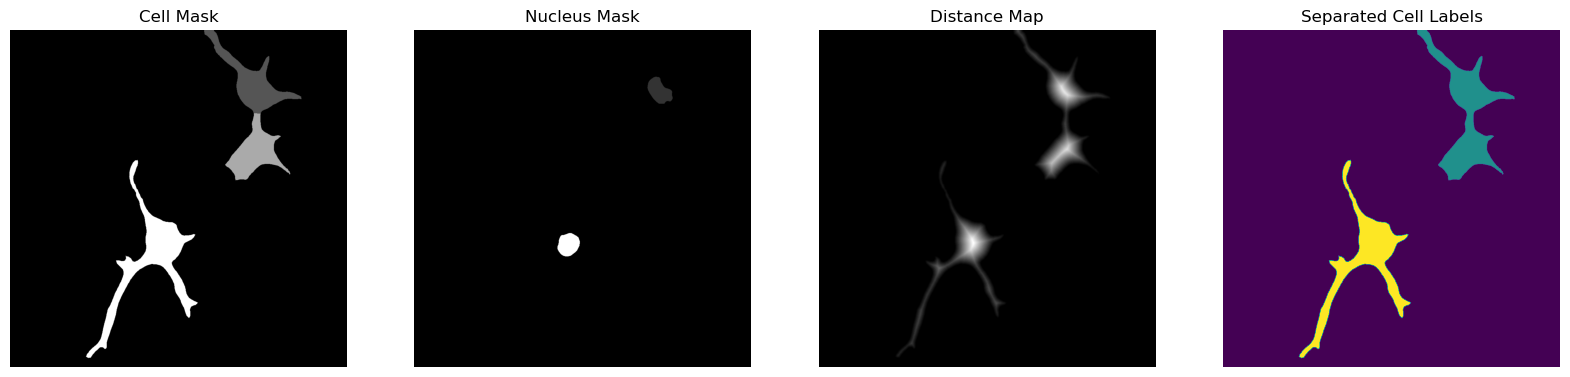

In [170]:
# Plotting the results including the distance map
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(mask_cell[-2], cmap='gray')
ax[0].set_title('Cell Mask')

ax[1].imshow(mask_nucleus_copy[-2], cmap='gray')
ax[1].set_title('Nucleus Mask')

ax[2].imshow(distance_maps[-2], cmap='gray')
ax[2].set_title('Distance Map')

ax[3].imshow(mask_label[-2])
ax[3].set_title('Separated Cell Labels')

for a in ax:
    a.axis('off')

plt.show()

In [171]:
np.unique(mask_label[-1])

array([0, 1], dtype=int32)

### Creating cytoplasm mask

In [172]:
# To match intensity values (= labels) of ROIs in nucleus image to intensity values of ROIs in whole cell image

for nucleus_image, cell_image in zip(mask_nucleus_copy, mask_label):
    # Create a dictionary to store coordinates and corresponding intensity values from mask_cell
    coordinates_intensity = {}

    # Store coordinates and intensity values from cell_image in the dictionary
    for cell_label in regionprops(cell_image):
        for coord in cell_label.coords:
            coordinates_intensity[tuple(coord)] = cell_image[coord[0], coord[1]]

    # Update nucleus_image based on the mapped coordinates and intensity values
    for nucleus_label in regionprops(nucleus_image):
        for coord in nucleus_label.coords:
            if tuple(coord) in coordinates_intensity:
                nucleus_image[coord[0], coord[1]] = coordinates_intensity[tuple(coord)]

In [173]:
print(np.unique(mask_label[1]))
print(np.unique(mask_nucleus_copy[1]))

[0 1]
[0 1]


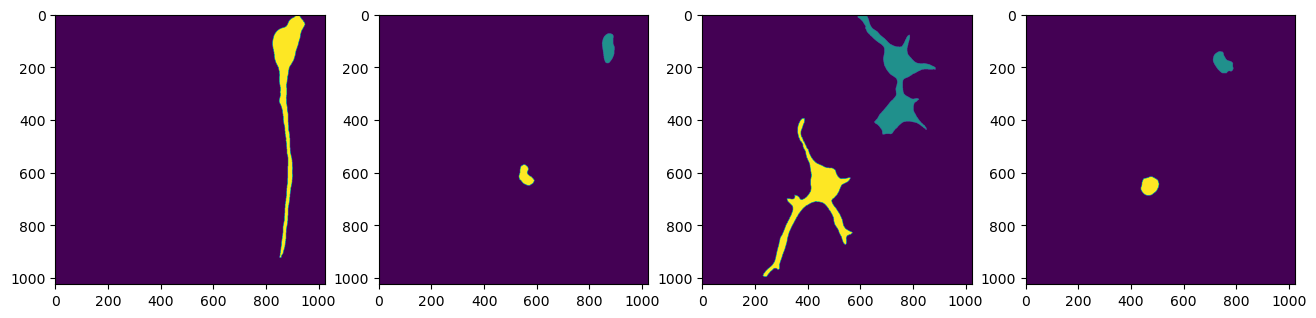

In [174]:
# Plot results of label matching

fig, ax = plt.subplots(1, 4, figsize = (16,4))
ax[0].imshow(mask_label[-1])
ax[1].imshow(mask_nucleus_copy[-1])
ax[2].imshow(mask_label[-2])
ax[3].imshow(mask_nucleus_copy[-2])

In [175]:
# Substract nucleus mask from cell mask and store as binary cytoplasm mask

def subtract_nucleus_from_cell(cell_mask, nucleus_mask):
    """
    Subtract the nucleus mask from the cell mask and return the cytoplasm mask.
    """
    # Create a copy of the cell mask to modify
    cytoplasm_mask = cell_mask.copy()
    
    # Set the areas where nucleus label is present to 0 in the cell mask
    cytoplasm_mask[nucleus_mask > 0] = 0
    
    return cytoplasm_mask

# List to store cytoplasm masks
mask_cytoplasm = []

for cell, nucleus in zip(mask_label, mask_nucleus_copy):
    # Subtract nucleus mask from cell mask
    cytoplasm_mask = subtract_nucleus_from_cell(cell, nucleus)
    
    mask_cytoplasm.append(cytoplasm_mask)

# Check results
for i, cytoplasm in enumerate(mask_cytoplasm):
    print(f"Unique values in cytoplasm mask {i}: {np.unique(cytoplasm)}")


Unique values in cytoplasm mask 0: [0 1]
Unique values in cytoplasm mask 1: [0 1]
Unique values in cytoplasm mask 2: [0 1]
Unique values in cytoplasm mask 3: [0 1 2]
Unique values in cytoplasm mask 4: [0 1 2]
Unique values in cytoplasm mask 5: [0 1]
Unique values in cytoplasm mask 6: [0 1]
Unique values in cytoplasm mask 7: [0 2]
Unique values in cytoplasm mask 8: [0 1]
Unique values in cytoplasm mask 9: [0 1 2]
Unique values in cytoplasm mask 10: [0 1]


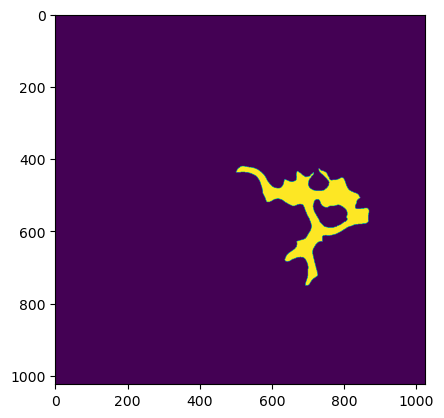

In [176]:
# Plot binary cytoplasm mask

plt.imshow(mask_cytoplasm[1])

### Mask corrections with Napari for overlapping cells

Click pasteur pipette to pick a label. Use paint brush to draw a line to separate two labels. Fill entire area with according label with fill bucket option. To create background, select label 0 and use the paint brush to draw and bucket to fill up.

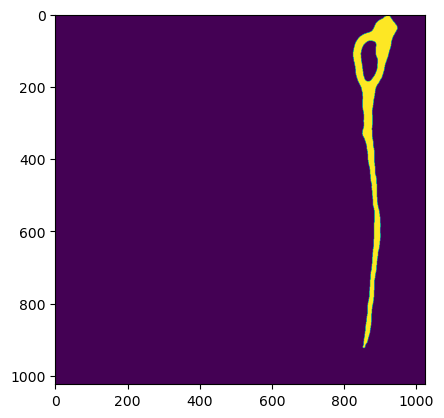

In [178]:
# Create copies of cytoplasm masks for manipulation in Napari

mask_cytoplasm_copy = mask_cytoplasm.copy()
plt.imshow(mask_cytoplasm_copy[-1])

In [179]:
# Initializes Napari viewer

#viewer = napari.Viewer()

In [180]:
# Adds images to Napari viewer

for i, img in enumerate(images):
    layer_name = f'image_{i}'  # Dynamically name each layer
    viewer.add_image(img, name=layer_name)

In [182]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_cytoplasm_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=0.2)

#### Reload cytoplasm and nuclei masks for final label matching

In [ ]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_cytoplasm_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=0.2)

In [183]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_nucleus_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=1)

### Saving finished masks

Only saves masks that have more than one label, i.e. more than background.

When saving, then the "halo" part from the file name should be deleted, so that the masks have the same name as the original images except the _ROIs at the end (for spot detection).

After saving, images where no masks were created have to be removed from the Selected_for_analysis folder.

In [ ]:
# Save cytoplasm masks and corrected nuclei masks - ADJUST relative path names
# Please provide the path to the output directory

mask_cytoplasm_output_dir = Path(r'/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Cytoplasm')
mask_cytoplasm_dir = mask_cytoplasm_output_dir

mask_nucleus_output_dir = Path(r'/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Nucleus')
mask_nucleus_dir =mask_nucleus_output_dir


In [185]:
# Save mask images with removing last part of the file name

for img, tiff_file in zip(mask_cytoplasm_copy, mask_nucleus_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    
    # Replace spaces with underscores
    file_name = file_name.replace(' ', '_')
    
    # Remove the second-to-last part
    parts = file_name.split('_')
    if len(parts) > 2:  # Ensure there are enough parts to modify
        file_name = '_'.join(parts[:-2] + parts[-1:])
    
    print(file_name)
    
    # Check if the image has more than just the background (label 0)
    if len(np.unique(img)) > 1:  # This checks for more than one unique value
        # Define the output file path
        output_file = os.path.join(mask_cytoplasm_dir, file_name + '.tif')
        print(output_file)
        
        # Save the manipulated image as a TIFF
        tf.imwrite(output_file, img)
    else:
        print(f"Image {file_name} has only background (label 0), not saving.")


10_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Cytoplasm/10_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs.tif
11_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Cytoplasm/11_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs.tif
1_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Cytoplasm/1_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs.tif
2_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Cytoplasm/2_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_ROIs.tif
3_17z-0-5_640-20-100ms_500g_561-30-50ms-

In [187]:
# Save mask images with removing last part of the file name

for img, tiff_file in zip(mask_nucleus_copy, mask_nucleus_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    
    # Replace spaces with underscores
    file_name = file_name.replace(' ', '_')
    
    print(file_name)
    
    # Check if the image has more than just the background (label 0)
    if len(np.unique(img)) > 1:  # This checks for more than one unique value
        # Define the output file path
        output_file = os.path.join(mask_nucleus_dir, file_name + '.tif')
        print(output_file)
        
        # Save the manipulated image as a TIFF
        tf.imwrite(output_file, img)
    else:
        print(f"Image {file_name} has only background (label 0), not saving.")


10_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Nucleus/10_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs.tif
11_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Nucleus/11_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs.tif
1_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Nucleus/1_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs.tif
2_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs
/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250214_iNs/D5/Parthenolide8hrs/ROIs/Nucleus/2_17z-0-5_640-20-100ms_500g_561-30-50ms-1000g_488-10_50ms-50g_1_halo_ROIs.tif
3_17z-0-